In [ ]:
!apt-get update -qq
!apt-get install -y fonts-noto-core fonts-noto-extra


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-noto-core fonts-noto-extra
0 upgraded, 2 newly installed, 0 to remove and 11 not upgraded.
Need to get 84.6 MB of archives.
After this operation, 386 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-noto-core all 20201225-1build1 [12.2 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-noto-extra all 20201225-1build1 [72.4 MB]
Fetched 84.6 MB in 4s (22.3 MB/s)
Selecting previously unselected package fonts-noto-core.
(Reading database ... 117528 files and directories currently installed.)
Preparing to unpack .../fonts-noto-core_20201225-1build1_all.deb ...
Unpacking fonts-noto-cor

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams["axes.unicode_minus"] = False

print("✅ Reset to default fonts (English should be back).")


✅ Reset to default fonts (English should be back).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.listdir('/content/drive/MyDrive/cse424_dataset')


['dev.csv', 'test.csv', 'train.csv', 'unlabelled_data.csv']

In [ ]:
import pandas as pd

base = "/content/drive/MyDrive/cse424_dataset"
train = pd.read_csv(base + "/train.csv")
dev   = pd.read_csv(base + "/dev.csv")
test  = pd.read_csv(base + "/test.csv")

print(train.shape, dev.shape, test.shape)
print(train.columns)
train.head(5)


(10839, 8) (1205, 8) (3012, 8)
Index(['domain', 'date', 'title', 'content', 'label', 'translated_title',
       'translated_content', 'categories'],
      dtype='object')


,domain,date,title,content,label,translated_title,translated_content,categories
0,https://topdhaka.com/%e0%a6%97%e0%a6%b2%e0%a6%...,2021-07-12 00:00:00+00:00,গলায় বিধেঁছে মাছের কাঁ’টা ? জেনে নিন ছাড়িয়ে ন...,মাছ ভালবাসেন না এমন বাঙালির সংখ্যাটা খুব একটা ...,1,You know five ways to get out of it.,The number of Bengalis who do not love fish is...,International
1,https://www.nbtimes24.com/archives/29343,2021-10-28 00:00:00+00:00,"সমালোচনা জীবনের একটা অংশ, এটা সহ্য করাও একটা আ...",1 hour ago\n2 hours ago\n2 hours ago\nটি-টোয়ে...,0,"Criticism is part of life, it's also an art: M...",The Bangladesh national cricket team has been ...,Sports
2,https://citynewszet.com/archives/71013,2021-09-27 00:00:00+00:00,এয়ার ফ্রেশনার ব্যবহার করে রোগ ঢেকে আনছেন না তো?,ঘরে কিংবা গাড়িতে দুর্গন্ধ ছড়ালেই এয়ার ফ্রেশনার...,1,Aren't you using air-fressioners to cover the ...,Air pressure is used when it stinks in the hom...,Economy
3,http://www.newsholder21.com/?p=30457,2021-10-07 00:00:00+00:00,সিজারের পরপরই সন্তানকে রেখে প্রেমিকের সঙ্গে পা...,যশোর ২৫০ শয্যা জেনারেল হাসপাতালে সন্তান জন্ম দ...,0,"Shortly after Caesar, Mother left her child an...",Shortly after the birth of a child in the Jess...,International
4,https://twentyfourbd.com/archives/3203,2021-03-25 00:00:00+00:00,চুলের জন্য সিনেমা থেকে বাদ পড়লেন নায়ক বাপ্পী,নির্মাতা দেলোয়ার জাহান ঝন্টু গত ১৭ অক্টোবর বাপ...,0,Hero Bappi dropped out of the movie for his hair,"The filmmaker, Delwar Jahan Jhantu, announced ...",Entertainment


Basic Dataset Information

In [ ]:
text_col = "title"
label_col = "label"

print("Train:", train.shape)
print("Dev:", dev.shape)
print("Test:", test.shape)

print("\nColumns:", list(train.columns))


Train: (10839, 8)
Dev: (1205, 8)
Test: (3012, 8)

Columns: ['domain', 'date', 'title', 'content', 'label', 'translated_title', 'translated_content', 'categories']


Missing Values and Duplicate Check

In [ ]:
print("Missing values in train:")
print(train[[text_col, label_col]].isna().sum())

print("\nDuplicate titles in train:")
print(train.duplicated(subset=[text_col]).sum())


Missing values in train:
title    0
label    0
dtype: int64

Duplicate titles in train:
370


Class distribution BEFORE cleaning

In [ ]:

print("Class distribution before cleaning:")
print(train[label_col].value_counts())


Class distribution before cleaning:
label
0    7080
1    3759
Name: count, dtype: int64


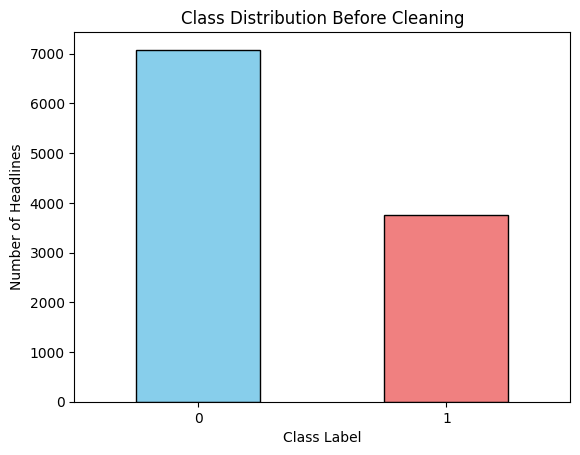

In [ ]:
import matplotlib.pyplot as plt

class_counts_before = train[label_col].value_counts()

plt.figure()
class_counts_before.plot(
    kind="bar",
    color=["skyblue", "lightcoral"],
    edgecolor="black"
)

plt.title("Class Distribution Before Cleaning")
plt.xlabel("Class Label")
plt.ylabel("Number of Headlines")
plt.xticks(rotation=0)
plt.show()


**Preprocessing**

Removing Duplicate Titles

In [ ]:
before = train.shape[0]

train = train.drop_duplicates(subset=[text_col])

after = train.shape[0]

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicates removed:", before - after)


Rows before removing duplicates: 10839
Rows after removing duplicates: 10469
Duplicates removed: 370


Class Distribution

In [ ]:
print("Class distribution after removing duplicates:")
print(train[label_col].value_counts())


Class distribution after removing duplicates:
label
0    6908
1    3561
Name: count, dtype: int64


 Headline length BEFORE cleaning

In [ ]:
# Headline length BEFORE cleaning
train["title_length_before"] = train["title"].apply(
    lambda x: len(str(x).split())
)


Remove URL ,HTML tags,Normalize Spaces

In [ ]:
import re

def clean_title(text):
    text = "" if pd.isna(text) else str(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)   # remove URLs
    text = re.sub(r"<.*?>", " ", text)              # remove HTML tags
    text = re.sub(r"\s+", " ", text).strip()        # normalize spaces
    return text

train["clean_title"] = train["title"].apply(clean_title)
dev["clean_title"]   = dev["title"].apply(clean_title)
test["clean_title"]  = test["title"].apply(clean_title)

# Show proof
train[["title", "clean_title"]].head(10)


,title,clean_title
0,গলায় বিধেঁছে মাছের কাঁ’টা ? জেনে নিন ছাড়িয়ে ন...,গলায় বিধেঁছে মাছের কাঁ’টা ? জেনে নিন ছাড়িয়ে ন...
1,"সমালোচনা জীবনের একটা অংশ, এটা সহ্য করাও একটা আ...","সমালোচনা জীবনের একটা অংশ, এটা সহ্য করাও একটা আ..."
2,এয়ার ফ্রেশনার ব্যবহার করে রোগ ঢেকে আনছেন না তো?,এয়ার ফ্রেশনার ব্যবহার করে রোগ ঢেকে আনছেন না তো?
3,সিজারের পরপরই সন্তানকে রেখে প্রেমিকের সঙ্গে পা...,সিজারের পরপরই সন্তানকে রেখে প্রেমিকের সঙ্গে পা...
4,চুলের জন্য সিনেমা থেকে বাদ পড়লেন নায়ক বাপ্পী,চুলের জন্য সিনেমা থেকে বাদ পড়লেন নায়ক বাপ্পী
5,ছোট হচ্ছে চীনের গেমিং বাজার - Techzoom.TV,ছোট হচ্ছে চীনের গেমিং বাজার - Techzoom.TV
6,প্রতিমন্ত্রীর কাছে নানির বাড়িতে বিমানবন্দর চাল...,প্রতিমন্ত্রীর কাছে নানির বাড়িতে বিমানবন্দর চাল...
7,ছবিটিতে প্রথমে কী দেখেছেন তার ওপর নির্ভর করছে ...,ছবিটিতে প্রথমে কী দেখেছেন তার ওপর নির্ভর করছে ...
8,চিত্রনায়ক ও প্রযোজক শাকিবের বিরুদ্ধে গুলশান থা...,চিত্রনায়ক ও প্রযোজক শাকিবের বিরুদ্ধে গুলশান থা...
9,পশ্চিমবঙ্গে মনোনয়ন পেয়েছেন বাংলাদেশের জয়া আহসান,পশ্চিমবঙ্গে মনোনয়ন পেয়েছেন বাংলাদেশের জয়া আহসান


**EDA**


Headline Length Analysis

In [ ]:
# Calculate headline length (number of words)
train["title_length"] = train["clean_title"].apply(lambda x: len(x.split()))

print("Headline Length Statistics (Training Set)")
print("Minimum length:", train["title_length"].min())
print("Maximum length:", train["title_length"].max())
print("Mean length:", round(train["title_length"].mean(), 2))
print("Median length:", train["title_length"].median())
print("Mode length:", train["title_length"].mode()[0])


Headline Length Statistics (Training Set)
Minimum length: 2
Maximum length: 30
Mean length: 8.33
Median length: 8.0
Mode length: 7


Distribution of Headline Lengths

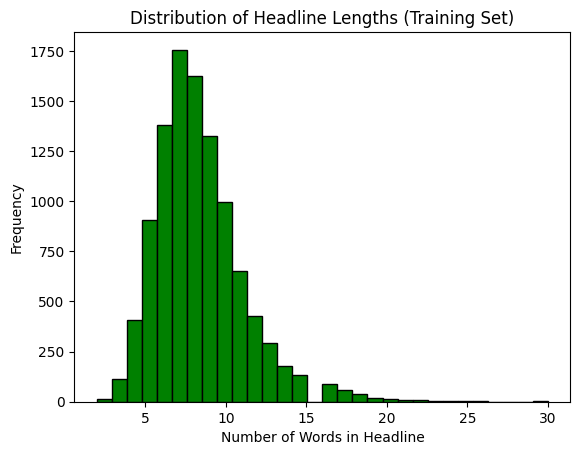

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(
    train["title_length"],
    bins=30,
    color="green",
    edgecolor="black"
)

plt.title("Distribution of Headline Lengths (Training Set)")
plt.xlabel("Number of Words in Headline")
plt.ylabel("Frequency")
plt.show()


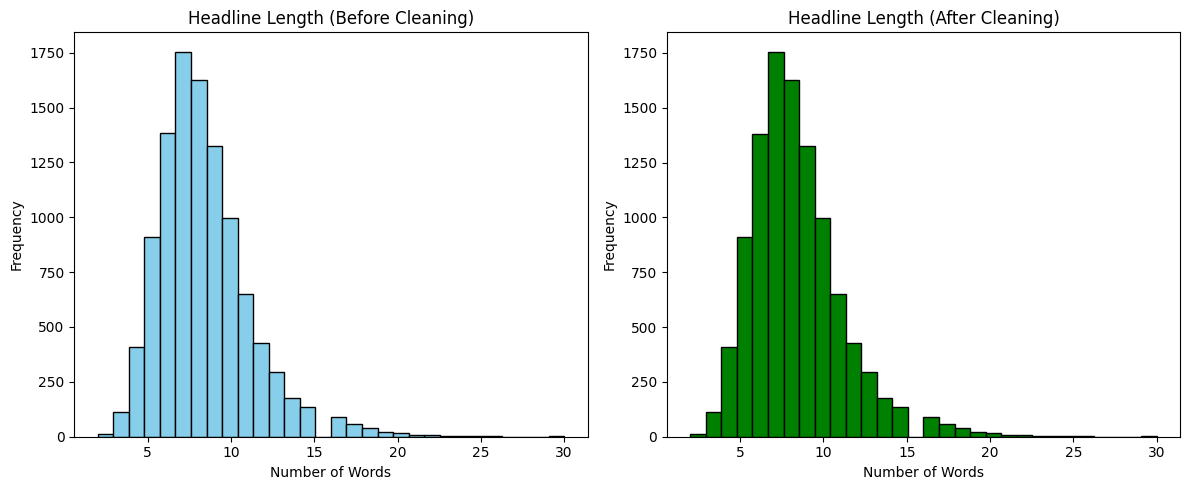

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Before cleaning
plt.subplot(1,2,1)
plt.hist(train["title_length_before"], bins=30, color="skyblue", edgecolor="black")
plt.title("Headline Length (Before Cleaning)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

# After cleaning
plt.subplot(1,2,2)
plt.hist(train["title_length"], bins=30, color="green", edgecolor="black")
plt.title("Headline Length (After Cleaning)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


Class Distribution of Clickbait vs Non-Clickbait

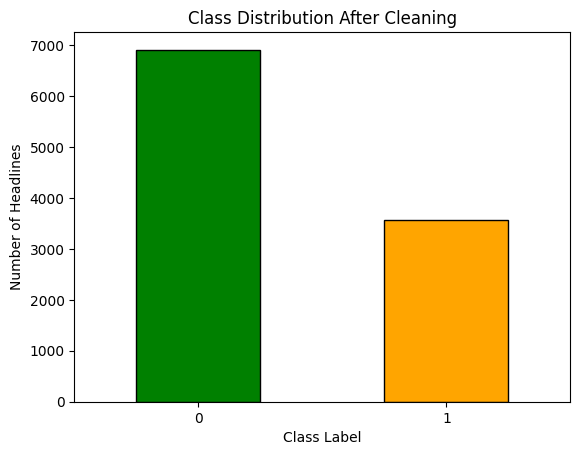

In [ ]:
import matplotlib.pyplot as plt

class_counts = train[label_col].value_counts()

plt.figure()
class_counts.plot(
    kind="bar",
    color=["green", "orange"],
    edgecolor="black"
)

plt.title("Class Distribution After Cleaning")
plt.xlabel("Class Label")
plt.ylabel("Number of Headlines")
plt.xticks(rotation=0)
plt.show()


Logistic Regression

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# TF-IDF Vectorization

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train = tfidf.fit_transform(train["clean_title"])
y_train = train[label_col].astype(int)

X_dev = tfidf.transform(dev["clean_title"])
y_dev = dev[label_col].astype(int)


# Logistic Regression Model

model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

model.fit(X_train, y_train)


# Predictions

y_pred_lr = model.predict(X_dev)


# Evaluation Metrics

print("Classification Report (Validation Set):")
print(classification_report(y_dev, y_pred_lr, digits=4))

print("Confusion Matrix:")
print(confusion_matrix(y_dev, y_pred_lr))


# Accuracy (Percentage Format)

accuracy = accuracy_score(y_dev, y_pred_lr)
print(f" Accuracy: {accuracy * 100:.2f}%")




Classification Report (Validation Set):
              precision    recall  f1-score   support

           0     0.7946    0.7128    0.7515       787
           1     0.5471    0.6531    0.5954       418

    accuracy                         0.6921      1205
   macro avg     0.6709    0.6830    0.6735      1205
weighted avg     0.7088    0.6921    0.6974      1205

Confusion Matrix:
[[561 226]
 [145 273]]
 Accuracy: 69.21%


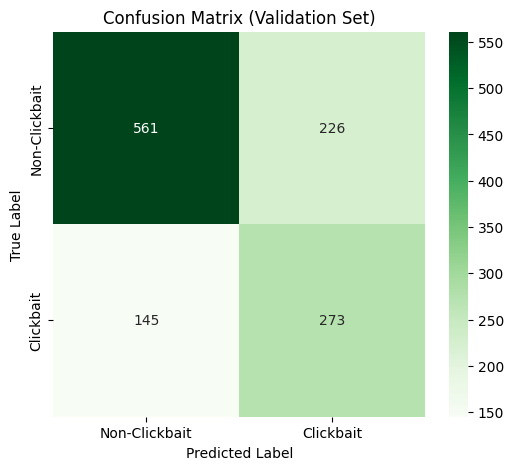

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_dev, y_pred_lr)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Non-Clickbait", "Clickbait"],
    yticklabels=["Non-Clickbait", "Clickbait"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Validation Set)")
plt.show()


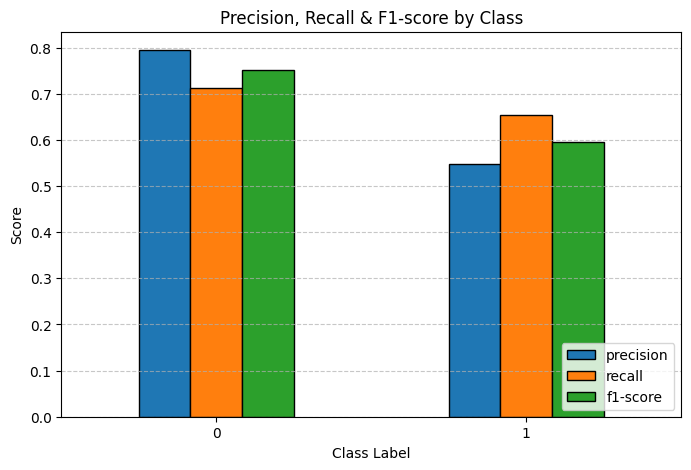

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

# Get classification report as dictionary
report = classification_report(y_dev, y_pred_lr, output_dict=True)

# Convert to DataFrame
metrics_df = pd.DataFrame(report).transpose()

# Select only class rows and metrics
metrics_df = metrics_df.loc[["0", "1"], ["precision", "recall", "f1-score"]]

# Plot
metrics_df.plot(
    kind="bar",
    figsize=(8,5),
    edgecolor="black"
)

plt.title("Precision, Recall & F1-score by Class")
plt.ylabel("Score")
plt.xlabel("Class Label")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


In [ ]:
#Multinomial Naive Bayes
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ===== Model 2: Multinomial Naive Bayes =====
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_dev)

print("="*55)
print("Multinomial Naive Bayes (Validation)")
print("="*55)

nb_acc = accuracy_score(y_dev, nb_pred)
print(f"Accuracy   : {nb_acc*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_dev, nb_pred, digits=4, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_dev, nb_pred))


Multinomial Naive Bayes (Validation)
Accuracy   : 70.87%

Classification Report:
              precision    recall  f1-score   support

           0     0.7088    0.9403    0.8083       787
           1     0.7081    0.2727    0.3938       418

    accuracy                         0.7087      1205
   macro avg     0.7084    0.6065    0.6010      1205
weighted avg     0.7086    0.7087    0.6645      1205

Confusion Matrix:
[[740  47]
 [304 114]]


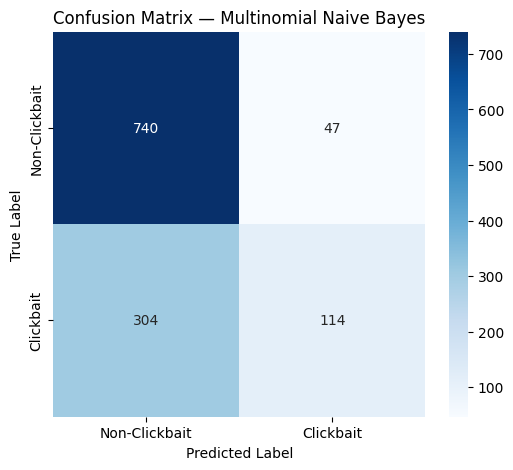

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_nb = confusion_matrix(y_dev, nb_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Clickbait", "Clickbait"],
    yticklabels=["Non-Clickbait", "Clickbait"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Multinomial Naive Bayes")
plt.show()


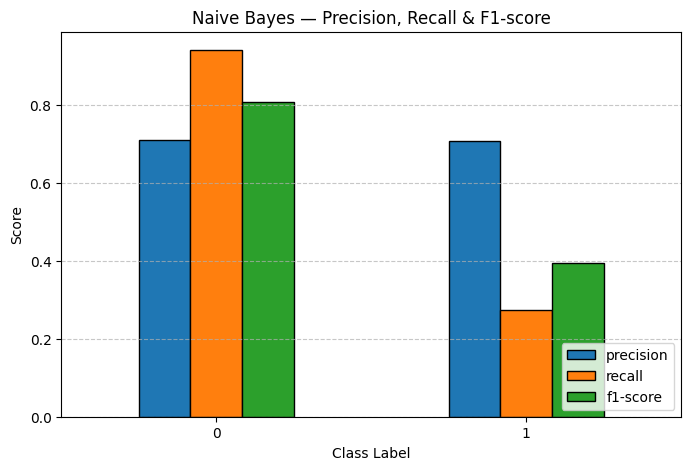

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

nb_report = classification_report(y_dev, nb_pred, output_dict=True)

nb_df = pd.DataFrame(nb_report).transpose()
nb_df = nb_df.loc[["0", "1"], ["precision", "recall", "f1-score"]]

nb_df.plot(
    kind="bar",
    figsize=(8,5),
    edgecolor="black"
)

plt.title("Naive Bayes — Precision, Recall & F1-score")
plt.ylabel("Score")
plt.xlabel("Class Label")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right")
plt.show()


In [ ]:
#Linear SVM
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ===== Model 3: Linear SVM =====
svm_model = LinearSVC(class_weight="balanced", max_iter=5000)
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_dev)

print("="*55)
print("Linear SVM (Validation)")
print("="*55)

svm_acc = accuracy_score(y_dev, svm_pred)
print(f"Accuracy   : {svm_acc*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_dev, svm_pred, digits=4, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_dev, svm_pred))


Linear SVM (Validation)
Accuracy   : 67.47%

Classification Report:
              precision    recall  f1-score   support

           0     0.7786    0.7014    0.7380       787
           1     0.5262    0.6244    0.5711       418

    accuracy                         0.6747      1205
   macro avg     0.6524    0.6629    0.6545      1205
weighted avg     0.6910    0.6747    0.6801      1205

Confusion Matrix:
[[552 235]
 [157 261]]


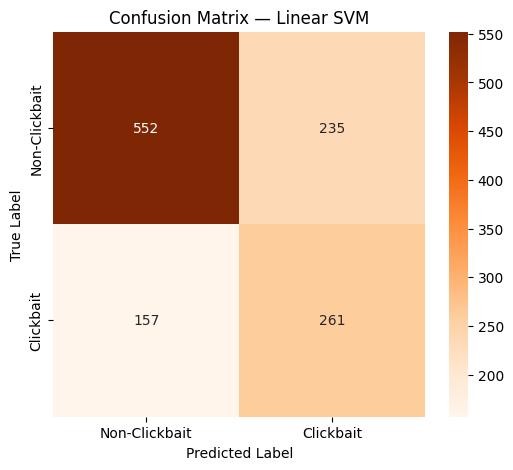

In [ ]:
cm_svm = confusion_matrix(y_dev, svm_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Non-Clickbait", "Clickbait"],
    yticklabels=["Non-Clickbait", "Clickbait"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Linear SVM")
plt.show()


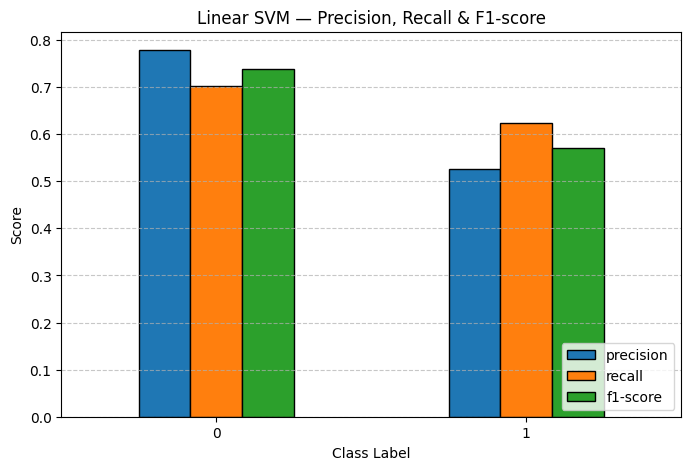

In [ ]:
svm_report = classification_report(y_dev, svm_pred, output_dict=True)

svm_df = pd.DataFrame(svm_report).transpose()
svm_df = svm_df.loc[["0", "1"], ["precision", "recall", "f1-score"]]

svm_df.plot(
    kind="bar",
    figsize=(8,5),
    edgecolor="black"
)

plt.title("Linear SVM — Precision, Recall & F1-score")
plt.ylabel("Score")
plt.xlabel("Class Label")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(loc="lower right")
plt.show()


In [ ]:
#KMeans
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# ---- KMeans Clustering ----
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train)

# Compare clusters with true labels (analysis only)
ari = adjusted_rand_score(y_train, clusters)
nmi = normalized_mutual_info_score(y_train, clusters)

print("="*55)
print("KMeans Clustering (Unsupervised)")
print("="*55)
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Info (NMI): {nmi:.4f}")


KMeans Clustering (Unsupervised)
Adjusted Rand Index (ARI): 0.0079
Normalized Mutual Info (NMI): 0.0006


In [ ]:
import pandas as pd

cluster_df = pd.DataFrame({
    "Cluster": clusters,
    "True Label": y_train
})

print("\nCluster vs True Label distribution:")
print(pd.crosstab(cluster_df["Cluster"], cluster_df["True Label"]))



Cluster vs True Label distribution:
True Label     0     1
Cluster               
0           6132  3102
1            776   459


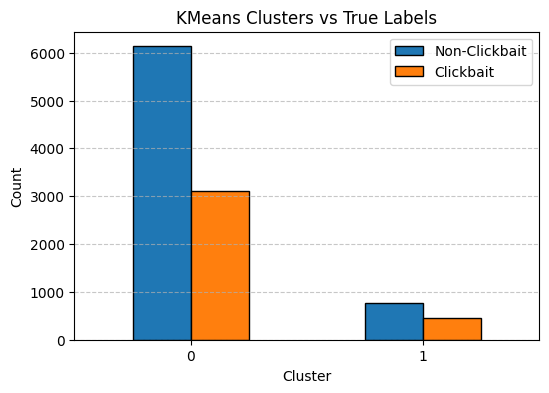

In [ ]:
import matplotlib.pyplot as plt

pd.crosstab(cluster_df["Cluster"], cluster_df["True Label"]).plot(
    kind="bar",
    figsize=(6,4),
    edgecolor="black"
)

plt.title("KMeans Clusters vs True Labels")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(["Non-Clickbait", "Clickbait"])
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models_summary = []

# Logistic Regression
models_summary.append([
    "Logistic Regression",
    accuracy_score(y_dev, y_pred_lr) * 100,
    precision_score(y_dev, y_pred_lr, average="weighted"),
    recall_score(y_dev, y_pred_lr, average="weighted"),
    f1_score(y_dev, y_pred_lr, average="weighted")
])

# Naive Bayes
models_summary.append([
    "Multinomial Naive Bayes",
    accuracy_score(y_dev, nb_pred) * 100,
    precision_score(y_dev, nb_pred, average="weighted"),
    recall_score(y_dev, nb_pred, average="weighted"),
    f1_score(y_dev, nb_pred, average="weighted")
])

# Linear SVM
models_summary.append([
    "Linear SVM",
    accuracy_score(y_dev, svm_pred) * 100,
    precision_score(y_dev, svm_pred, average="weighted"),
    recall_score(y_dev, svm_pred, average="weighted"),
    f1_score(y_dev, svm_pred, average="weighted")
])

comparison_df = pd.DataFrame(
    models_summary,
    columns=["Model", "Accuracy (%)", "Precision", "Recall", "F1-score"]
)

comparison_df


,Model,Accuracy (%),Precision,Recall,F1-score
0,Logistic Regression,69.211618,0.708755,0.692116,0.697362
1,Multinomial Naive Bayes,70.871369,0.708556,0.708714,0.664510
2,Linear SVM,67.468880,0.691024,0.674689,0.680089


Model Comparison: Accuracy, Precision, Recall, F1-score

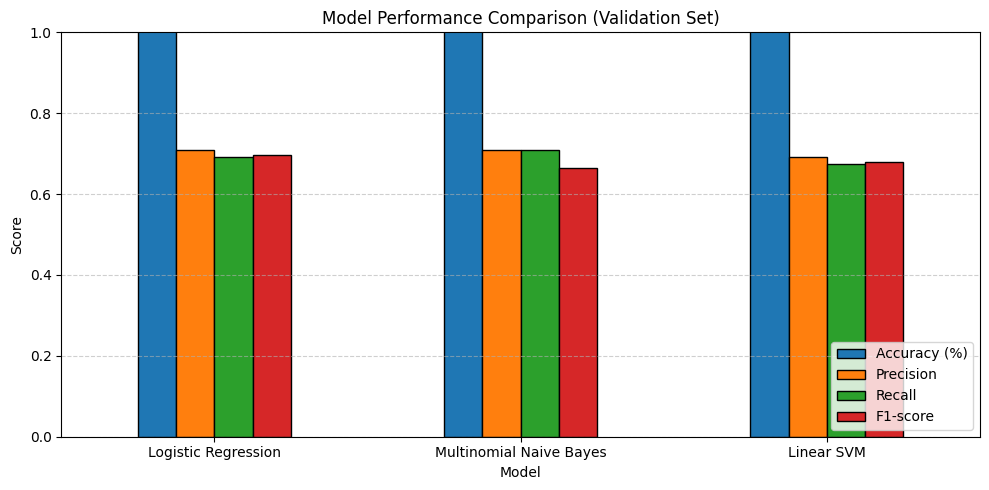

In [ ]:
import matplotlib.pyplot as plt

# Make a copy so we don't change the original
plot_df = comparison_df.copy()

# Convert accuracy to percentage if needed
# (Your table already shows Accuracy (%) so we keep it as is)
metrics = ["Accuracy (%)", "Precision", "Recall", "F1-score"]

ax = plot_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10, 5),
    edgecolor="black"
)

plt.title("Model Performance Comparison (Validation Set)")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)  # keep same scale for precision/recall/f1
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [ ]:
#Retrain Logistic Regression
# Final Model: Logistic Regression
final_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

final_model.fit(X_train, y_train)

final_pred = final_model.predict(X_dev)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Final Model Evaluation (Logistic Regression)")
print("-" * 50)
print(classification_report(y_dev, final_pred, digits=4))
print(f"Accuracy: {accuracy_score(y_dev, final_pred) * 100:.2f}%")


Final Model Evaluation (Logistic Regression)
--------------------------------------------------
              precision    recall  f1-score   support

           0     0.7946    0.7128    0.7515       787
           1     0.5471    0.6531    0.5954       418

    accuracy                         0.6921      1205
   macro avg     0.6709    0.6830    0.6735      1205
weighted avg     0.7088    0.6921    0.6974      1205

Accuracy: 69.21%


Extract TF-IDF Feature Names + Coefficients

In [ ]:
import pandas as pd

# Get feature names from TF-IDF
feature_names = tfidf.get_feature_names_out()

# Get coefficients from logistic regression
coefficients = final_model.coef_[0]

# Create DataFrame
coef_df = pd.DataFrame({
    "word": feature_names,
    "coefficient": coefficients
})

# Sort by coefficient
coef_df = coef_df.sort_values(by="coefficient", ascending=False)


Show Top Words (Explainability)

In [ ]:
# Top words indicating CLICKBAIT (label = 1)
top_clickbait = coef_df.head(15)

# Top words indicating NON-CLICKBAIT (label = 0)
top_non_clickbait = coef_df.sort_values(by="coefficient").head(15)


print("Top Clickbait Indicative Words:")
display(top_clickbait)

print("\nTop Non-Clickbait Indicative Words:")
display(top_non_clickbait)


Top Clickbait Indicative Words:


,word,coefficient
743,ইর,5.188948
1032,এই,4.898398
282,আপন,3.362613
3869,রইল,2.707706
3284,বলল,2.485828
3980,রণ,2.133892
1203,এমন,2.081410
1261,ওট,2.009262
4976,৮ট,2.002997
40,অত পর,1.968878



Top Non-Clickbait Indicative Words:


,word,coefficient
3166,বর,-1.869182
942,উদ,-1.847514
4461,সদস,-1.723648
641,ইত,-1.598618
1274,ওম,-1.577209
3700,মস,-1.576256
332,আম ইর,-1.539844
2095,ডল,-1.518711
4634,সড়ক,-1.506692
1268,ওপ,-1.490233


XAI Visualization (Bar Plots)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import glob

# Find Bengali font file (installed via apt)
font_paths = glob.glob("/usr/share/fonts/**/NotoSerifBengali-*.ttf", recursive=True) + \
             glob.glob("/usr/share/fonts/**/NotoSansBengali-*.ttf", recursive=True)

if not font_paths:
    raise FileNotFoundError("Bengali font not found. Run apt install for bengali fonts first.")

BENGALI_FP = fm.FontProperties(fname=font_paths[0])
print("✅ Bengali font file:", font_paths[0])


✅ Bengali font file: /usr/share/fonts/truetype/noto/NotoSerifBengali-ExtraBold.ttf


/tmp/ipython-input-1150850570.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(top_clickbait["word"], fontproperties=BENGALI_FP)
/tmp/ipython-input-1150850570.py:14: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Bengali.
  plt.tight_layout()
/tmp/ipython-input-1150850570.py:14: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Bengali.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Bengali.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Bengali.
  fig.canvas.print_figure(bytes_io, **kw)


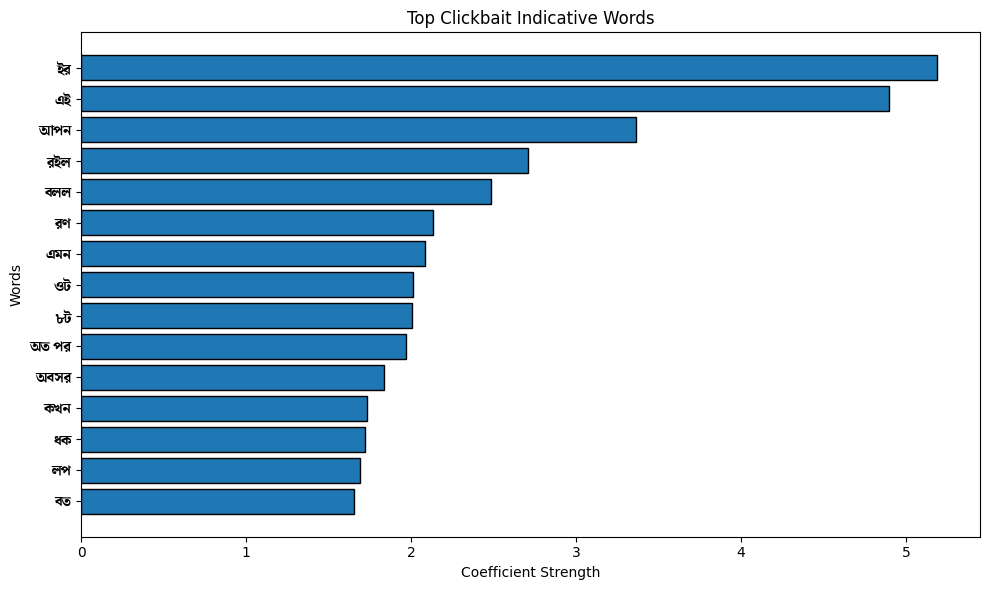

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(top_clickbait["word"], top_clickbait["coefficient"], edgecolor="black")

plt.xlabel("Coefficient Strength")
plt.ylabel("Words")
plt.title("Top Clickbait Indicative Words")

# Bengali y-axis labels ONLY
ax = plt.gca()
ax.set_yticklabels(top_clickbait["word"], fontproperties=BENGALI_FP)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



Model on testdata

Final Model Evaluation (TEST Set) - Logistic Regression
Accuracy   : 68.19%
Precision  : 54.22%
Recall     : 61.79%
F1-score   : 57.76%

Classification Report (Test Set):
              precision    recall  f1-score   support

           0     0.7755    0.7167    0.7449      1952
           1     0.5422    0.6179    0.5776      1060

    accuracy                         0.6819      3012
   macro avg     0.6589    0.6673    0.6613      3012
weighted avg     0.6934    0.6819    0.6861      3012

Confusion Matrix (Test Set):
[[1399  553]
 [ 405  655]]


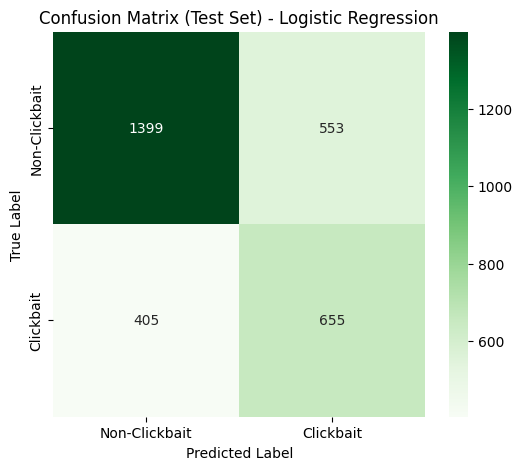

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# FINAL TEST EVALUATION
# =========================

# 1) Transform test using SAME fitted tfidf
X_test = tfidf.transform(test["clean_title"])
y_test = test[label_col].astype(int)

# 2) Predict using SAME trained model
y_test_pred = model.predict(X_test)

# 3) Print clean metrics
acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec  = recall_score(y_test, y_test_pred)
f1   = f1_score(y_test, y_test_pred)

print("="*55)
print("Final Model Evaluation (TEST Set) - Logistic Regression")
print("="*55)
print(f"Accuracy   : {acc*100:.2f}%")
print(f"Precision  : {prec*100:.2f}%")
print(f"Recall     : {rec*100:.2f}%")
print(f"F1-score   : {f1*100:.2f}%")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, digits=4))

print("Confusion Matrix (Test Set):")
cm_test = confusion_matrix(y_test, y_test_pred)
print(cm_test)

# 4) Confusion matrix plot
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_test, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Non-Clickbait", "Clickbait"],
    yticklabels=["Non-Clickbait", "Clickbait"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Test Set) - Logistic Regression")
plt.show()


In [ ]:
import pandas as pd

final_results = pd.DataFrame({
    "Dataset": ["Validation", "Test"],
    "Accuracy (%)": [69.21, 68.19],
    "Precision (%)": [54.71, 54.22],
    "Recall (%)": [65.31, 61.79],
    "F1-score (%)": [59.54, 57.76]
})

final_results


,Dataset,Accuracy (%),Precision (%),Recall (%),F1-score (%)
0,Validation,69.21,54.71,65.31,59.54
1,Test,68.19,54.22,61.79,57.76
